In [59]:
import numpy as np
import time
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
from IPython.display import display, HTML
from statsmodels import robust
import pickle
from scipy.ndimage import filters
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import auc
display(HTML("<style>.container { width:65% !important; }</style>"))

In [60]:
boris_dir = 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\'
boris_files = np.sort([boris_dir + x for x in os.listdir(boris_dir) if '.csv' in x and '._' not in x])
print('Sample boris files:')
print(boris_files)

Sample boris files:
['C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162B_d9_OBSmCD1_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162B_d9_OBSmCD1_t2.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162B_d9_OBSmCD1_t3.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162L2_d9_toyCD1_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162L2_d9_toyCD1_t2.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162L2_d9_toyCD1_t3.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162R_d9_toyCD1_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162R_d9_toyCD1_t2.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1162R_d9_toyCD1_t3.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1185_d9_OBSmCD1_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1185_d9_OBSmCD1_t2.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\1185_d9_OBSmCD1_t3.csv'
 'C:\\Users\\FalknerLab\\Desktop\\all_hf_labels\\29L_d9_OBSmCD1_t1.csv'
 'C:\\Users\\FalknerLab\\D

Wrangling:

In [145]:
from tqdm import tqdm

               # DISTANCES
feats_list1 =  ['proximity', 'resident2intruder head-head', 'resident2intruder head-tti', 'intruder2resident head-tti',
               # SOCIAL ORIENTATIONS
               'resident2intruder head2centroid angle', 'intruder2resident head2centroid angle',
               # SPEEDS
               'resident centroid roc 100 ms', 'intruder centroid roc 100 ms', 'resident head roc 100 ms', 'intruder head roc 100 ms',
               # POSTURAL INFORMATION
               'resident centroid2nose angle', 'intruder centroid2nose angle', 'resident tti2head', 'intruder tti2head']

               # DISTANCES
feats_list2 =  ['proximity', 'resident2intruder head-head', 'resident2intruder head-tti', 'intruder2resident head-tti',
               # SOCIAL ORIENTATIONS
               'resident2intruder head2centroid angle', 'intruder2resident head2centroid angle',
               # SPEEDS
               'resident centroid roc 100 ms', 'intruder centroid roc 100 ms', 'resident head roc 100 ms', 'intruder head roc 100 ms',
               'resident centroid roc 100 ms sum across lags', 'intruder centroid roc 100 ms sum across lags', 'resident head roc 100 ms sum across lags', 'intruder head roc 100 ms sum across lags',
               # IoU
               'ious',
               # POSTURAL INFORMATION
               'resident centroid2nose angle', 'intruder centroid2nose angle', 'resident tti2head', 'intruder tti2head']

               # DISTANCES
feats_list3 =  ['proximity', 'resident2intruder head-head', 'resident2intruder head-tti', 'intruder2resident head-tti',
               # SOCIAL ORIENTATIONS
               'resident2intruder head2centroid angle', 'intruder2resident head2centroid angle',
               # SPEEDS
               'resident centroid roc 100 ms', 'intruder centroid roc 100 ms', 'resident head roc 100 ms', 'intruder head roc 100 ms',
               'resident centroid roc 100 ms sum across lags', 'intruder centroid roc 100 ms sum across lags', 'resident head roc 100 ms sum across lags', 'intruder head roc 100 ms sum across lags',
               # IoU and pixel change
               'ious',
               # POSTURAL INFORMATION
               'resident centroid2nose angle', 'intruder centroid2nose angle', 'resident tti2head', 'intruder tti2head']

               # DISTANCES
feats_list4 =  ['proximity', 'resident2intruder head-head', 'resident2intruder head-tti', 'intruder2resident head-tti',
               # SOCIAL ORIENTATIONS
               'resident2intruder head2centroid angle', 'intruder2resident head2centroid angle',
               # SPEEDS
               'resident centroid roc 100 ms', 'intruder centroid roc 100 ms', 'resident head roc 100 ms', 'intruder head roc 100 ms', 'proximity roc 100 ms',
               'resident centroid roc 100 ms sum across lags', 'intruder centroid roc 100 ms sum across lags', 'resident head roc 100 ms sum across lags', 'intruder head roc 100 ms sum across lags',
               'proximity roc 100 ms sum across lags',
               # IoU and pixel change
               'ious',
               # POSTURAL INFORMATION
               'resident centroid2nose angle', 'intruder centroid2nose angle', 'resident tti2head', 'intruder tti2head']

               
feats_list5 =  ['ious sum across lags', 'resident centroid roc 50 ms', 'intruder centroid roc 50 ms', 'resident head roc 50 ms', 'intruder head roc 50 ms',
                'resident centroid roc 50 ms sum across lags', 'intruder centroid roc 50 ms sum across lags', 'resident head roc 50 ms sum across lags', 'intruder head roc 50 ms sum across lags',
                'resident centroid roc 500 ms', 'intruder centroid roc 500 ms', 'resident head roc 500 ms', 'intruder head roc 500 ms',
                'resident centroid roc 500 ms sum across lags', 'intruder centroid roc 500 ms sum across lags', 'resident head roc 500 ms sum across lags', 'intruder head roc 500 ms sum across lags']


feats_list = list(set(feats_list1 + feats_list2 + feats_list3 + feats_list4 + feats_list5))
feats_list.sort()
feats_list = np.asarray(feats_list)

# ── 1. Load ALL features for d9 sessions from both paths ─────────────────────
d9_patterns     = ['mCD1', 'OBSmCD1', 'toyCD1']
all_features_d9 = {}
n               = 4

for feats_path in [
    "S:\\jmig\\feature_processing\\processed_features_020924_parquets\\",
    "S:\\jmig\\feature_processing\\processed_features_not4training\\",
]:
    print(f'\nLoading from: {feats_path}')
    try:
        feat_pickles = np.sort([x for x in os.listdir(feats_path) if 'zscored' in x])
    except FileNotFoundError:
        print(f'  Path not found, skipping')
        continue

    d9_pickles = [x for x in feat_pickles if any(p in x for p in d9_patterns)]
    print(f'  Found {len(d9_pickles)} d9 sessions')

    for session in tqdm(d9_pickles):
        key = '_'.join(session.split('_')[:n])
        if key in all_features_d9:
            print(f'  Collision — {key} already loaded, skipping duplicate')
            continue
        try:
            z = pd.read_parquet(feats_path + session, columns=feats_list).astype(np.float32)
            all_features_d9[key] = z
        except Exception as e:
            print(f'  Error loading {session}: {e}')


Loading from: S:\jmig\feature_processing\processed_features_020924_parquets\
  Found 60 d9 sessions


100%|██████████| 60/60 [01:04<00:00,  1.07s/it]



Loading from: S:\jmig\feature_processing\processed_features_not4training\
  Found 27 d9 sessions


100%|██████████| 27/27 [00:30<00:00,  1.11s/it]


In [61]:
# ── Updated behavior label constants ──────────────────────────────────────────
RESIDENT_UNILATERAL = ['resident_unilateral_attack']
INTRUDER_UNILATERAL = ['intruder_unilateral_attack']
RESIDENT_RESISTANCE = ['resident_attack_with_resistance', 'fight_from_resident_with_resistance']
INTRUDER_RESISTANCE = ['intruder_attack_with_resistance', 'fight_from_intruder_with_resistance']
RESIDENT_FLEE       = ['resident_flee']
IGNORE_BEHAVIORS    = ['fight', 'attack/fight']

REQUIRED_BEHAVIORS  = (RESIDENT_UNILATERAL + INTRUDER_UNILATERAL +
                       RESIDENT_RESISTANCE  + INTRUDER_RESISTANCE  +  RESIDENT_FLEE)

def format_boris_new(boris_path, boris_fps=40):
    """
    Parse BORIS CSV export. Handles three formats:

    Format A: 16-row metadata header, columns Time/Behavior/Status,
              frame = Time * FPS
    Format B: flat CSV with full column set including 'Image index',
              frame taken directly from 'Image index'
    Empty:    16-row header but no data rows — returns None
    """
    try:
        # ── Format A: skiprows=16, minimal columns ────────────────────────
        df = pd.read_csv(boris_path, skiprows=16)
        assert 'Time' in df.columns and 'Behavior' in df.columns, \
            "Format A columns not found"

        # Empty file — header present but no data
        if len(df) == 0:
            print(f"  Empty file (Format A header, no data): {boris_path}")
            return None

        fps_val   = df['FPS'].dropna().iloc[0] if 'FPS' in df.columns else boris_fps
        df['Frame'] = (df['Time'].astype(float) * fps_val).astype(int)
        state_col = 'Status' if 'Status' in df.columns else 'Behavior type'
        df        = df[['Frame', 'Behavior', state_col]].copy()
        df.columns = ['Frame', 'Behavior', 'State']
        print(f"  Parsed as Format A (skiprows=16), FPS={fps_val}")

    except Exception as e:
        # ── Format B: flat CSV, use Image index directly ──────────────────
        print(f"  Format A failed ({e}), trying Format B...")
        try:
            df = pd.read_csv(boris_path)

            # Empty file with no usable columns
            if len(df) == 0 or 'Image index' not in df.columns:
                print(f"  Empty or unrecognized file: {boris_path}")
                return None

            df['Frame']   = df['Image index'].astype(int)
            state_col     = 'Status' if 'Status' in df.columns else 'Behavior type'
            df            = df[['Frame', 'Behavior', state_col]].copy()
            df.columns    = ['Frame', 'Behavior', 'State']
            print(f"  Parsed as Format B (flat CSV with Image index)")

        except Exception as e2:
            print(f"  Could not parse {boris_path}: {e2}")
            return None

    print(f"  Behaviors found: {df['Behavior'].unique()}")
    return df

def extract_frames_from_boris(behs, behavior_name):
    """
    Given a parsed BORIS df and a behavior name,
    return array of all frame indices where behavior is active.
    """
    rows = behs[behs['Behavior'] == behavior_name].reset_index(drop=True)
    if len(rows) == 0:
        return np.array([])

    frames = []
    for i in range(0, len(rows) - 1, 2):
        start_f = rows.loc[i,   'Frame']
        stop_f  = rows.loc[i+1, 'Frame']
        frames.append(np.arange(start_f, stop_f + 1))

    return np.concatenate(frames) if frames else np.array([])

In [62]:
# ── Behavior constants ─────────────────────────────────────────────────────────
RESIDENT_UNILATERAL = ['resident_unilateral_attack']
INTRUDER_UNILATERAL = ['intruder_unilateral_attack']
RESIDENT_RESISTANCE = ['resident_attack_with_resistance', 'fight_from_resident_with_resistance']
INTRUDER_RESISTANCE = ['intruder_attack_with_resistance', 'fight_from_intruder_with_resistance']
RESIDENT_FLEE       = ['resident_flee']

ALL_BEHAVIOR_GROUPS = {
    'resident_unilateral': RESIDENT_UNILATERAL,
    'intruder_unilateral': INTRUDER_UNILATERAL,
    'resident_resistance': RESIDENT_RESISTANCE,
    'intruder_resistance': INTRUDER_RESISTANCE,
    'resident_flee':       RESIDENT_FLEE,
}

# ── Group mapping from filename ────────────────────────────────────────────────
def parse_filename(fname):
    """Extract animal_id, session (t1/t2/t3), and group from filename."""
    base  = os.path.basename(fname).replace('.csv', '')
    # e.g. 87L2_d9_OBSmCD1_t3
    match = re.match(r'^(.+?)_d\d+_(mCD1|OBSmCD1|toyCD1)_t(\d+)$', base)
    if match:
        animal  = match.group(1)
        stim    = match.group(2)
        session = int(match.group(3))
        group   = {'mCD1': 'EXP', 'OBSmCD1': 'OBS', 'toyCD1': 'NON'}[stim]
        return animal, session, group
    return None, None, None

# ── Main loader ────────────────────────────────────────────────────────────────
def load_all_sessions(boris_files, boris_fps=40):
    """
    For each CSV, parse BORIS annotations and produce a one-hot encoded
    DataFrame with one row per frame and binary columns per behavior group.
    Returns a dict keyed by (animal, session, group) -> DataFrame.
    """
    session_dfs = {}

    for path in boris_files:
        animal, session, group = parse_filename(path)
        if animal is None:
            print(f'  Could not parse filename: {os.path.basename(path)}')
            continue

        print(f'\n=== {os.path.basename(path)} | {animal} | {group} | t{session} ===')
        behs = format_boris_new(path, boris_fps=boris_fps)

        if behs is None:
            print(f'  Skipping — could not parse.')
            continue

        # Determine total frame count from annotation span
        n_frames = int(behs['Frame'].max()) + 1

        # Build one-hot columns
        arrays = {}
        for col_name, behavior_list in ALL_BEHAVIOR_GROUPS.items():
            col = np.zeros(n_frames, dtype=int)
            for beh in behavior_list:
                if beh in behs['Behavior'].values:
                    frames = extract_frames_from_boris(behs, beh)
                    if len(frames):
                        col[np.clip(frames, 0, n_frames - 1)] = 1
            arrays[col_name] = col

        df = pd.DataFrame(arrays)
        df.index.name = 'frame'

        # Attach metadata as columns for easy groupby later
        df.insert(0, 'animal',  animal)
        df.insert(1, 'group',   group)
        df.insert(2, 'session', session)
        df.insert(3, 'time_s',  np.arange(n_frames) / boris_fps)

        key = (animal, session, group)
        session_dfs[key] = df

        # Quick summary
        for col in ALL_BEHAVIOR_GROUPS:
            n = arrays[col].sum()
            print(f'  {col:<30} {n:>6} frames  ({n/boris_fps:.2f}s)')

    print(f'\n{"="*60}')
    print(f'Loaded {len(session_dfs)} sessions total.')
    return session_dfs

# ── Run ────────────────────────────────────────────────────────────────────────
session_dfs = load_all_sessions(boris_files, boris_fps=40)

# ── Concatenate into one master DataFrame ─────────────────────────────────────
master_df = pd.concat(session_dfs.values(), ignore_index=True)
print(f'\nMaster DataFrame shape: {master_df.shape}')
print(master_df.head())
print(f'\nGroup counts (sessions):')
print(master_df.groupby('group')['animal'].nunique())


=== 1162B_d9_OBSmCD1_t1.csv | 1162B | OBS | t1 ===
  Format A failed (Format A columns not found), trying Format B...
  Parsed as Format B (flat CSV with Image index)
  Behaviors found: ['resident_unilateral_attack' 'resident_attack_with_resistance']
  resident_unilateral               406 frames  (10.15s)
  intruder_unilateral                 0 frames  (0.00s)
  resident_resistance                14 frames  (0.35s)
  intruder_resistance                 0 frames  (0.00s)
  resident_flee                       0 frames  (0.00s)

=== 1162B_d9_OBSmCD1_t2.csv | 1162B | OBS | t2 ===
  Format A failed (No columns to parse from file), trying Format B...
  Parsed as Format B (flat CSV with Image index)
  Behaviors found: ['resident_attack_with_resistance']
  resident_unilateral                 0 frames  (0.00s)
  intruder_unilateral                 0 frames  (0.00s)
  resident_resistance               152 frames  (3.80s)
  intruder_resistance                 0 frames  (0.00s)
  resident_flee  

In [63]:
# Save session_dfs to pickle
import pickle

with open('boris_labels_hf.pickle', 'wb') as f:
    pickle.dump(session_dfs, f)

print('Saved session_dfs to boris_labels_hf.pickle')

Saved session_dfs to boris_labels_hf.pickle


In [64]:
# ── Add combined columns to session_dfs ───────────────────────────────────────
for key, df in session_dfs.items():
    df['attacks_delivered'] = (
        df[['resident_unilateral', 'resident_resistance']]
        .sum(axis=1) > 0).astype(int)
    df['attacks_received'] = (
        df[['intruder_unilateral', 'intruder_resistance']]
        .sum(axis=1) > 0).astype(int)
    session_dfs[key] = df

Stats:

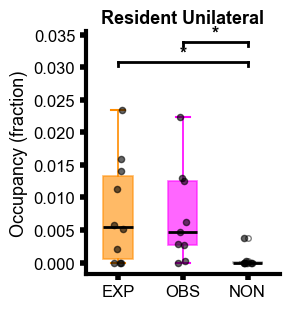

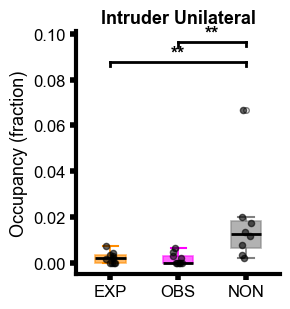

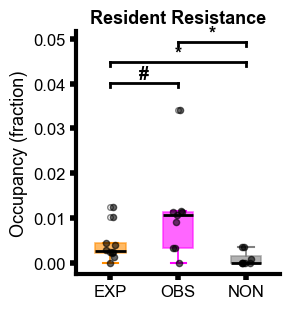

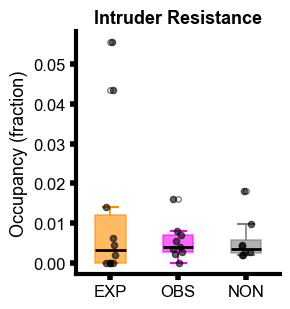

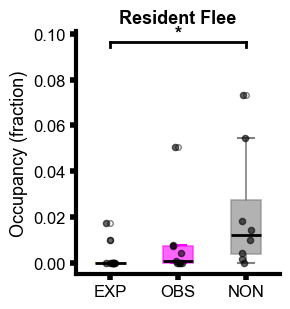


Occupancy statistics — omnibus gate + pairwise FDR-BH

resident_unilateral
  Omnibus: Kruskal-Wallis  stat=8.081  p=0.0176
  Comparison         Test           Stat      p_raw     p_corr   Sig   n1   n2
  ──────────────────────────────────────────────────────────────────────
  EXP vs OBS        MWU          44.500     1.0000     1.0000    ns   10    9
  EXP vs NON        MWU          64.000     0.0257     0.0385     *   10    8
  OBS vs NON        MWU          64.000     0.0061     0.0183     *    9    8

intruder_unilateral
  Omnibus: Kruskal-Wallis  stat=12.460  p=0.0020
  Comparison         Test           Stat      p_raw     p_corr   Sig   n1   n2
  ──────────────────────────────────────────────────────────────────────
  EXP vs OBS        MWU          50.000     0.6977     0.6977    ns   10    9
  EXP vs NON        MWU           6.000     0.0028     0.0044    **   10    8
  OBS vs NON        MWU           5.000     0.0030     0.0044    **    9    8

resident_resistance
  Omnibus: Kr

In [74]:
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kruskal, f_oneway, mannwhitneyu, ttest_ind
from statsmodels.stats.multitest import multipletests

matplotlib.rcParams['font.family'] = 'Arial'

GROUP_ORDER  = ['EXP', 'OBS', 'NON']
GROUP_COLORS = {'EXP': 'darkorange', 'OBS': 'magenta', 'NON': 'gray'}
BEHAVIORS    = list(ALL_BEHAVIOR_GROUPS.keys())
# BEHAVIORS = ['attacks_delivered', 'attacks_received', 'resident_flee']
FPS          = 40

# ── Compute per-animal occupancy ───────────────────────────────────────────────
def compute_occupancy(session_dfs):
    """
    For each (animal, group), average occupancy across sessions.
    Occupancy = frames_active / total_frames per session, then mean across sessions.
    Returns DataFrame: animal, group, behavior, occupancy
    """
    records = []
    # Group by animal+group
    animal_sessions = {}
    for (animal, session, group), df in session_dfs.items():
        key = (animal, group)
        if key not in animal_sessions:
            animal_sessions[key] = []
        animal_sessions[key].append(df)

    for (animal, group), dfs in animal_sessions.items():
        for beh in BEHAVIORS:
            sess_occ = []
            for df in dfs:
                n_total  = len(df)
                n_active = df[beh].sum()
                sess_occ.append(n_active / n_total if n_total > 0 else np.nan)
            records.append({
                'animal':    animal,
                'group':     group,
                'behavior':  beh,
                'occupancy': np.nanmean(sess_occ),
            })

    return pd.DataFrame(records)

occ_df = compute_occupancy(session_dfs)

# ── Stats helpers ──────────────────────────────────────────────────────────────
def test_normality(groups_data, alpha=0.05):
    """Returns True if all groups are normally distributed."""
    for g in groups_data:
        if len(g) < 3:
            return False
        _, p = shapiro(g)
        if p <= alpha:
            return False
    return True

def posthoc_tests(groups_data, group_names, parametric):
    """All pairwise comparisons with FDR correction."""
    pairs   = [(i, j) for i in range(len(group_names))
                       for j in range(i+1, len(group_names))]
    pvals   = []
    stats_  = []
    results = []

    for i, j in pairs:
        a, b = groups_data[i], groups_data[j]
        if len(a) < 2 or len(b) < 2:
            pvals.append(np.nan)
            stats_.append(np.nan)
        else:
            if parametric:
                s, p = ttest_ind(a, b)
                test_used = 't-test'
            else:
                s, p = mannwhitneyu(a, b, alternative='two-sided')
                test_used = 'MWU'
            pvals.append(p)
            stats_.append(s)

    # FDR correction
    corrected = np.full(len(pvals), np.nan)
    valid_p   = [(idx, p) for idx, p in enumerate(pvals) if not np.isnan(p)]
    if valid_p:
        _, corr, _, _ = multipletests(
            [p for _, p in valid_p], method='fdr_bh')
        for rank, (idx, _) in enumerate(valid_p):
            corrected[idx] = corr[rank]

    test_used = 't-test' if parametric else 'MWU'
    for idx, (i, j) in enumerate(pairs):
        results.append({
            'group1':    group_names[i],
            'group2':    group_names[j],
            'test':      test_used,
            'stat':      stats_[idx],
            'p_raw':     pvals[idx],
            'p_corr':    corrected[idx],
            'n1':        len(groups_data[i]),
            'n2':        len(groups_data[j]),
        })
    return results

def get_sig(p):
    if np.isnan(p):   return ''
    if p < 0.001:     return '***'
    if p < 0.01:      return '**'
    if p < 0.05:      return '*'
    if p < 0.1:       return '#'
    return 'ns'

# ── Plot ───────────────────────────────────────────────────────────────────────
def plot_occupancy_behavior(occ_df, behavior, ax,
                             axis_linewidth=1.5,
                             tick_length=4,
                             tick_width=1.5):

    beh_df = occ_df[occ_df['behavior'] == behavior]

    groups_data = [
        beh_df[beh_df['group'] == g]['occupancy'].dropna().values
        for g in GROUP_ORDER
    ]

    # ── Omnibus test ──
    valid_groups = [g for g in groups_data if len(g) >= 3]
    parametric   = test_normality(valid_groups)

    if len(valid_groups) >= 2:
        if parametric:
            stat, p_omni = f_oneway(*valid_groups)
            test_label   = 'one-way ANOVA'
        else:
            stat, p_omni = kruskal(*valid_groups)
            test_label   = 'Kruskal-Wallis'
    else:
        p_omni, test_label = np.nan, 'insufficient data'

    posthoc = posthoc_tests(groups_data, GROUP_ORDER, parametric)

    # ── Boxplot ──
    positions = np.arange(len(GROUP_ORDER))
    for pi, (g, pts) in enumerate(zip(GROUP_ORDER, groups_data)):
        color = GROUP_COLORS[g]
        if len(pts) == 0:
            continue
        ax.boxplot(pts,
                   positions=[pi], widths=0.45, patch_artist=True,
                   showfliers=True,
                   medianprops=dict(color='black', linewidth=2),
                   boxprops=dict(facecolor=color, alpha=0.6,
                                 linewidth=1.2, edgecolor=color),
                   whiskerprops=dict(color=color, linewidth=1.2),
                   capprops=dict(color=color, linewidth=1.5),
                   flierprops=dict(marker='o', color=color,
                                   markeredgecolor='black',
                                   markersize=4, alpha=0.5))
        jitter = np.random.default_rng(42 + pi).uniform(-0.08, 0.08, size=len(pts))
        ax.scatter(np.full(len(pts), pi) + jitter, pts,
                   color='black', s=20, alpha=0.6, zorder=5)

    # ── Significance brackets ──
    ax.autoscale()
    y_max  = ax.get_ylim()[1]
    step   = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12
    for level, res in enumerate(posthoc):
        sig = get_sig(res['p_corr'])
        if sig in ('', 'ns'):
            continue
        g1_idx = GROUP_ORDER.index(res['group1'])
        g2_idx = GROUP_ORDER.index(res['group2'])
        y_br   = y_max + step * (level + 1)
        ax.plot([g1_idx, g2_idx], [y_br, y_br], color='black', linewidth=2)
        ax.plot([g1_idx, g1_idx], [y_br - step*0.2, y_br], color='black', linewidth=2)
        ax.plot([g2_idx, g2_idx], [y_br - step*0.2, y_br], color='black', linewidth=2)
        ax.text((g1_idx + g2_idx) / 2, y_br, sig,
                ha='center', va='bottom', fontsize=13,
                fontweight='bold', fontfamily='Arial')

    # ── Formatting ──
    ax.set_xticks(positions)
    ax.set_xticklabels(GROUP_ORDER, fontsize=14, fontfamily='Arial')
    ax.set_ylabel('Occupancy (fraction)', fontsize=13, fontfamily='Arial')
    ax.set_title(behavior.replace('_', ' ').title(),
                 fontsize=13, fontweight='bold', fontfamily='Arial')

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial')
        tick.set_fontsize(12)

    # ── Axis spine width ──
    for spine in ax.spines.values():
        spine.set_linewidth(axis_linewidth)

    # ── Tick length and width ──
    ax.tick_params(axis='both',
                   length=tick_length,
                   width=tick_width)

    sns.despine(ax=ax)
    return posthoc, p_omni, test_label


# ── One figure per behavior ────────────────────────────────────────────────────
all_stats = {}
for beh in BEHAVIORS:
    fig, ax = plt.subplots(figsize=(3, 3.2))
    posthoc, p_omni, test_label = plot_occupancy_behavior(
        occ_df, beh, ax,
        axis_linewidth=3,
        tick_length=4,
        tick_width=4,
    )
    all_stats[beh] = {'omnibus_p': p_omni, 'test': test_label, 'posthoc': posthoc}
    plt.tight_layout()
    plt.savefig(f'.\\figures\\fig1\\occupancies_{beh}.svg', dpi=300)
    plt.show()
    plt.close()

# ── Print summary table ────────────────────────────────────────────────────────
print(f'\n{"="*90}')
print(f'Occupancy statistics — omnibus gate + pairwise FDR-BH')
print(f'{"="*90}')

for beh, s in all_stats.items():
    omni_p    = s['omnibus_p']
    omni_p_s  = f'{omni_p:.4f}' if not np.isnan(omni_p) else 'n/a'
    
    # retrieve omnibus stat — recompute from stored posthoc context
    # (stat wasn't stored, so we pull it cleanly here)
    beh_df      = occ_df[occ_df['behavior'] == beh]
    groups_data = [beh_df[beh_df['group'] == g]['occupancy'].dropna().values
                   for g in GROUP_ORDER]
    valid_groups = [g for g in groups_data if len(g) >= 3]
    parametric   = test_normality(valid_groups)
    if len(valid_groups) >= 2:
        if parametric:
            omni_stat, _ = f_oneway(*valid_groups)
        else:
            omni_stat, _ = kruskal(*valid_groups)
    else:
        omni_stat = np.nan
    omni_stat_s = f'{omni_stat:.3f}' if not np.isnan(omni_stat) else 'n/a'

    print(f'\n{beh}')
    print(f'  Omnibus: {s["test"]}  stat={omni_stat_s}  p={omni_p_s}')
    print(f'  {"Comparison":<18} {"Test":<8} {"Stat":>10} '
          f'{"p_raw":>10} {"p_corr":>10} {"Sig":>5} '
          f'{"n1":>4} {"n2":>4}')
    print(f'  {"─"*70}')
    for ph in s['posthoc']:
        sig    = get_sig(ph['p_corr'])
        stat_s = f'{ph["stat"]:>10.3f}' if not np.isnan(ph['stat']) else '       n/a'
        p_r_s  = f'{ph["p_raw"]:>10.4f}' if not np.isnan(ph['p_raw']) else '       n/a'
        p_c_s  = f'{ph["p_corr"]:>10.4f}' if not np.isnan(ph['p_corr']) else '       n/a'
        print(f'  {ph["group1"]} vs {ph["group2"]:<10} {ph["test"]:<8} '
              f'{stat_s} {p_r_s} {p_c_s} {sig:>5} '
              f'{ph["n1"]:>4} {ph["n2"]:>4}')

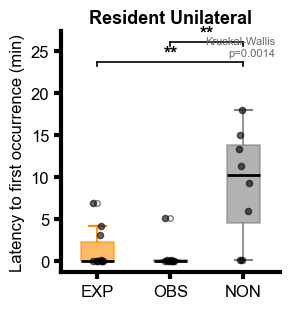


── resident_unilateral | Kruskal-Wallis  stat=13.112  p=0.0014 ──
  Comparison         Test           Stat      p_raw     p_corr   Sig   n1   n2
  ─────────────────────────────────────────────────────────────────
  EXP vs OBS        MWU          59.000     0.2703     0.2703    ns   10    9
  EXP vs NON        MWU           7.000     0.0021     0.0031    **   10    8
  OBS vs NON        MWU           3.000     0.0006     0.0017    **    9    8


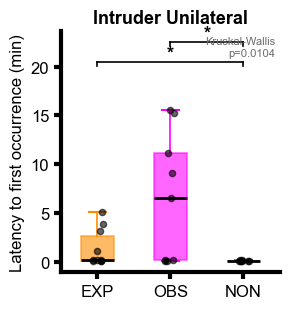


── intruder_unilateral | Kruskal-Wallis  stat=9.125  p=0.0104 ──
  Comparison         Test           Stat      p_raw     p_corr   Sig   n1   n2
  ─────────────────────────────────────────────────────────────────
  EXP vs OBS        MWU          29.000     0.2057     0.2057    ns   10    9
  EXP vs NON        MWU          68.000     0.0117     0.0175     *   10    8
  OBS vs NON        MWU          62.000     0.0111     0.0175     *    9    8


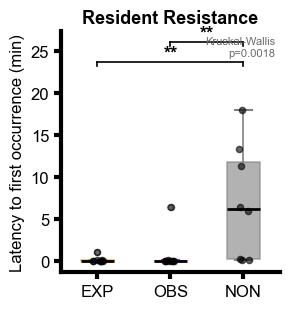


── resident_resistance | Kruskal-Wallis  stat=12.600  p=0.0018 ──
  Comparison         Test           Stat      p_raw     p_corr   Sig   n1   n2
  ─────────────────────────────────────────────────────────────────
  EXP vs OBS        MWU          56.000     0.3913     0.3913    ns   10    9
  EXP vs NON        MWU           4.000     0.0005     0.0016    **   10    8
  OBS vs NON        MWU           6.000     0.0025     0.0037    **    9    8


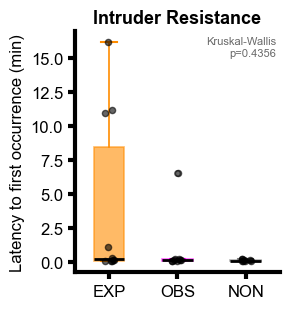


── intruder_resistance | Kruskal-Wallis  stat=1.662  p=0.4356 ──
  Comparison         Test           Stat      p_raw     p_corr   Sig   n1   n2
  ─────────────────────────────────────────────────────────────────
  EXP vs OBS        MWU          52.000     0.5956     0.5956    ns   10    9
  EXP vs NON        MWU          54.000     0.2370     0.5956    ns   10    8
  OBS vs NON        MWU          44.000     0.4807     0.5956    ns    9    8


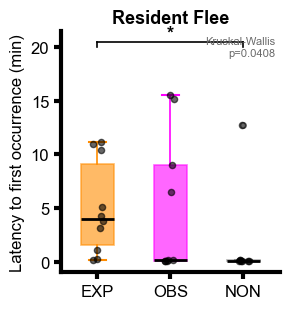


── resident_flee | Kruskal-Wallis  stat=6.396  p=0.0408 ──
  Comparison         Test           Stat      p_raw     p_corr   Sig   n1   n2
  ─────────────────────────────────────────────────────────────────
  EXP vs OBS        MWU          55.000     0.4379     0.4379    ns   10    9
  EXP vs NON        MWU          68.000     0.0117     0.0350     *   10    8
  OBS vs NON        MWU          53.000     0.1139     0.1709    ns    9    8


In [69]:
def compute_latency_to_first_global(session_dfs, fps=40):
    records = []
    animal_sessions = {}
    for (animal, session, group), df in session_dfs.items():
        key = (animal, group)
        if key not in animal_sessions:
            animal_sessions[key] = []
        animal_sessions[key].append((session, df))

    for (animal, group), sess_list in animal_sessions.items():
        sess_list = sorted(sess_list, key=lambda x: x[0])
        concat_df = pd.concat([df for _, df in sess_list], ignore_index=True)
        for beh in BEHAVIORS:
            active_frames = np.where(concat_df[beh].values == 1)[0]
            latency       = active_frames[0] / fps if len(active_frames) > 0 else len(concat_df)
            records.append({
                'animal':    animal,
                'group':     group,
                'behavior':  beh,
                'latency_s': latency,
                'latency_m': latency / 40 / 60,  # convert to minutes
            })

    return pd.DataFrame(records)

lat_global_df = compute_latency_to_first_global(session_dfs, fps=FPS)

# ── Plot ───────────────────────────────────────────────────────────────────────
os.makedirs('./figures/fig1/', exist_ok=True)
# BEHAVIORS = ['attacks_delivered', 'attacks_received', 'resident_flee']

for beh in BEHAVIORS:
    fig, ax = plt.subplots(figsize=(3, 3.2))
    beh_df  = lat_global_df[lat_global_df['behavior'] == beh]

    groups_data = [
        beh_df[beh_df['group'] == g]['latency_m'].dropna().values
        for g in GROUP_ORDER
    ]

    # Omnibus
    valid_groups = [g for g in groups_data if len(g) >= 3]
    parametric   = test_normality(valid_groups)
    if len(valid_groups) >= 2:
        if parametric:
            stat, p_omni = f_oneway(*valid_groups)
            test_label   = 'one-way ANOVA'
        else:
            stat, p_omni = kruskal(*valid_groups)
            test_label   = 'Kruskal-Wallis'
    else:
        p_omni, test_label = np.nan, 'n/a'

    posthoc = posthoc_tests(groups_data, GROUP_ORDER, parametric)

    # Boxplots + dots
    for pi, (g, pts) in enumerate(zip(GROUP_ORDER, groups_data)):
        color = GROUP_COLORS[g]
        if len(pts) == 0:
            continue
        ax.boxplot(pts,
                   positions=[pi], widths=0.45, patch_artist=True,
                   showfliers=True,
                   medianprops=dict(color='black', linewidth=2),
                   boxprops=dict(facecolor=color, alpha=0.6,
                                 linewidth=1.2, edgecolor=color),
                   whiskerprops=dict(color=color, linewidth=1.2),
                   capprops=dict(color=color, linewidth=1.5),
                   flierprops=dict(marker='o', color=color,
                                   markeredgecolor='black',
                                   markersize=4, alpha=0.5))
        jitter = np.random.default_rng(42 + pi).uniform(-0.08, 0.08, size=len(pts))
        ax.scatter(np.full(len(pts), pi) + jitter, pts,
                   color='black', s=20, alpha=0.6, zorder=5)

    # Significance brackets
    ax.autoscale()
    y_max = ax.get_ylim()[1]
    step  = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12
    for level, res in enumerate(posthoc):
        sig = get_sig(res['p_corr'])
        if sig in ('', 'ns'):
            continue
        g1_idx = GROUP_ORDER.index(res['group1'])
        g2_idx = GROUP_ORDER.index(res['group2'])
        y_br   = y_max + step * (level + 1)
        ax.plot([g1_idx, g2_idx], [y_br, y_br], color='black', linewidth=1.2)
        ax.plot([g1_idx, g1_idx], [y_br - step*0.2, y_br], color='black', linewidth=1.2)
        ax.plot([g2_idx, g2_idx], [y_br - step*0.2, y_br], color='black', linewidth=1.2)
        ax.text((g1_idx + g2_idx) / 2, y_br, sig,
                ha='center', va='bottom', fontsize=13,
                fontweight='bold', fontfamily='Arial')

    # Formatting
    ax.set_xticks(np.arange(len(GROUP_ORDER)))
    ax.set_xticklabels(GROUP_ORDER, fontsize=13, fontfamily='Arial')
    ax.set_ylabel('Latency to first occurrence (min)',
                  fontsize=12, fontfamily='Arial')
    ax.set_title(beh.replace('_', ' ').title(),
                 fontsize=13, fontweight='bold', fontfamily='Arial')

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial')
        tick.set_fontsize(12)

    # ── Axis spine width ──
    for spine in ax.spines.values():
        spine.set_linewidth(3)

    # ── Tick length and width ──
    ax.tick_params(axis='both', length=5, width=3)

    p_str = f'p={p_omni:.4f}' if not np.isnan(p_omni) else 'p=NA'
    ax.text(0.98, 0.98, f'{test_label}\n{p_str}',
            transform=ax.transAxes, fontsize=8, fontfamily='Arial',
            ha='right', va='top', color='dimgray')

    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(f'./figures/fig1/latency_global_{beh}.svg', dpi=300)
    plt.show()
    plt.close()

    print(f'\n── {beh} | {test_label}  stat={stat:.3f}  p={p_omni:.4f} ──')
    print(f'  {"Comparison":<18} {"Test":<8} {"Stat":>10} '
          f'{"p_raw":>10} {"p_corr":>10} {"Sig":>5} '
          f'{"n1":>4} {"n2":>4}')
    print(f'  {"─"*65}')
    for ph in posthoc:
        sig    = get_sig(ph['p_corr'])
        stat_s = f'{ph["stat"]:>10.3f}' if not np.isnan(ph['stat']) else '       n/a'
        p_r_s  = f'{ph["p_raw"]:>10.4f}'  if not np.isnan(ph['p_raw'])  else '       n/a'
        p_c_s  = f'{ph["p_corr"]:>10.4f}' if not np.isnan(ph['p_corr']) else '       n/a'
        print(f'  {ph["group1"]} vs {ph["group2"]:<10} {ph["test"]:<8} '
              f'{stat_s} {p_r_s} {p_c_s} {sig:>5} '
              f'{ph["n1"]:>4} {ph["n2"]:>4}')


Animal       Group  Conflict(s)   Resident Unilatera  Intruder Unilatera  Resident Resistanc  Intruder Resistanc  
--------------------------------------------------------------------------------
3095         EXP    15.10         0.000              0.045              0.189              0.767              
3096         EXP    0.72          1.000              0.000              0.000              0.000              
3097         EXP    6.95          0.640              0.000              0.076              0.284              
30B          EXP    10.75         0.000              0.000              0.037              0.963              
30L          EXP    5.53          0.000              0.167              0.122              0.710              
4013         EXP    2.52          0.465              0.000              0.366              0.168              
4014         EXP    16.07         0.659              0.218              0.123              0.000              
4015         EXP    17.82 

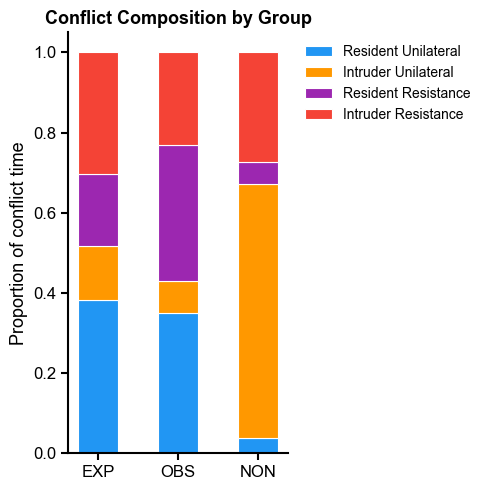

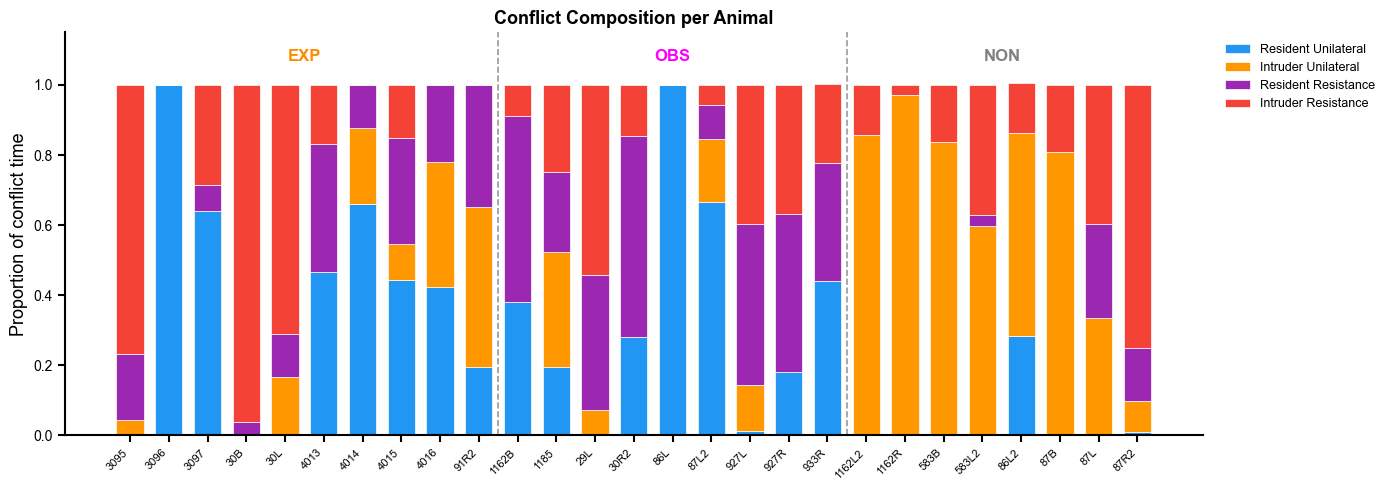

In [70]:
# ── Conflict behavior composition ─────────────────────────────────────────────
CONFLICT_BEHAVIORS = [
    'resident_unilateral',
    'intruder_unilateral',
    'resident_resistance',
    'intruder_resistance',
]

CONFLICT_COLORS = {
    'resident_unilateral': '#2196F3',   # blue
    'intruder_unilateral': '#FF9800',   # orange
    'resident_resistance': '#9C27B0',   # purple
    'intruder_resistance': '#F44336',   # red
}

CONFLICT_LABELS = {
    'resident_unilateral': 'Resident Unilateral',
    'intruder_unilateral': 'Intruder Unilateral',
    'resident_resistance': 'Resident Resistance',
    'intruder_resistance': 'Intruder Resistance',
}

def compute_conflict_proportions(session_dfs):
    """
    For each animal, concatenate all sessions and compute the proportion
    of total conflict frames occupied by each behavior type.
    Returns DataFrame: animal, group, + one column per conflict behavior (proportion).
    """
    records = []

    # Group sessions by animal
    animal_sessions = {}
    for (animal, session, group), df in session_dfs.items():
        key = (animal, group)
        if key not in animal_sessions:
            animal_sessions[key] = []
        animal_sessions[key].append((session, df))

    for (animal, group), sess_list in animal_sessions.items():
        sess_list  = sorted(sess_list, key=lambda x: x[0])
        concat_df  = pd.concat([df for _, df in sess_list], ignore_index=True)

        # Total conflict frames = any of the 4 behaviors active
        conflict_mask  = np.zeros(len(concat_df), dtype=bool)
        for beh in CONFLICT_BEHAVIORS:
            conflict_mask |= (concat_df[beh].values == 1)
        total_conflict = conflict_mask.sum()

        if total_conflict == 0:
            # Animal had no conflict at all — all proportions NaN
            row = {'animal': animal, 'group': group, 'total_conflict_s': 0}
            for beh in CONFLICT_BEHAVIORS:
                row[beh] = np.nan
            records.append(row)
            continue

        row = {
            'animal':           animal,
            'group':            group,
            'total_conflict_s': total_conflict / FPS,
        }
        for beh in CONFLICT_BEHAVIORS:
            n_frames   = concat_df[beh].sum()
            row[beh]   = n_frames / total_conflict  # proportion within conflict
        records.append(row)

    return pd.DataFrame(records)

conf_df = compute_conflict_proportions(session_dfs)

# ── Print per-animal summary ───────────────────────────────────────────────────
print(f'\n{"="*80}')
print(f'{"Animal":<12} {"Group":<6} {"Conflict(s)":<14}', end='')
for beh in CONFLICT_BEHAVIORS:
    print(f'{CONFLICT_LABELS[beh][:18]:<20}', end='')
print()
print('-'*80)
for _, row in conf_df.sort_values(['group','animal']).iterrows():
    print(f'{row["animal"]:<12} {row["group"]:<6} {row["total_conflict_s"]:<14.2f}', end='')
    for beh in CONFLICT_BEHAVIORS:
        val = row[beh]
        print(f'{val:.3f}{"":14}' if not np.isnan(val) else f'{"NaN":<20}', end='')
    print()

# ── Per-group mean proportions ─────────────────────────────────────────────────
def group_mean_proportions(conf_df):
    records = []
    for group in GROUP_ORDER:
        gdf = conf_df[conf_df['group'] == group]
        row = {'group': group}
        for beh in CONFLICT_BEHAVIORS:
            row[f'{beh}_mean'] = gdf[beh].dropna().mean()
            row[f'{beh}_sem']  = gdf[beh].dropna().sem()
            row[f'{beh}_n']    = gdf[beh].dropna().count()
        records.append(row)
    return pd.DataFrame(records)

group_props = group_mean_proportions(conf_df)

# ── Stats: group differences per behavior ─────────────────────────────────────
print(f'\n{"="*70}')
print('GROUP DIFFERENCES IN CONFLICT COMPOSITION (FDR-corrected)')
print(f'{"="*70}')

conf_stats = {}
for beh in CONFLICT_BEHAVIORS:
    groups_data = [
        conf_df[conf_df['group'] == g][beh].dropna().values
        for g in GROUP_ORDER
    ]
    valid_groups = [g for g in groups_data if len(g) >= 3]
    parametric   = test_normality(valid_groups)

    if len(valid_groups) >= 2:
        if parametric:
            stat, p_omni = f_oneway(*valid_groups)
            test_label   = 'ANOVA'
        else:
            stat, p_omni = kruskal(*valid_groups)
            test_label   = 'KW'
    else:
        p_omni, test_label = np.nan, 'n/a'

    posthoc = posthoc_tests(groups_data, GROUP_ORDER, parametric)
    conf_stats[beh] = {'p_omni': p_omni, 'test': test_label, 'posthoc': posthoc}

    print(f'\n{CONFLICT_LABELS[beh]} | {test_label} p={p_omni:.4f}')
    for ph in posthoc:
        sig = get_sig(ph['p_corr'])
        print(f'  {ph["group1"]} vs {ph["group2"]:<6} '
              f'p_raw={ph["p_raw"]:.4f}  p_corr={ph["p_corr"]:.4f}  {sig}')

# ── Figure 1: Stacked bar — group mean proportions ────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))

x      = np.arange(len(GROUP_ORDER))
bottom = np.zeros(len(GROUP_ORDER))

for beh in CONFLICT_BEHAVIORS:
    means = np.array([
        group_props.loc[group_props['group'] == g, f'{beh}_mean'].values[0]
        for g in GROUP_ORDER
    ])
    sems = np.array([
        group_props.loc[group_props['group'] == g, f'{beh}_sem'].values[0]
        for g in GROUP_ORDER
    ])
    bars = ax.bar(x, means, bottom=bottom, color=CONFLICT_COLORS[beh],
                  label=CONFLICT_LABELS[beh], width=0.5, edgecolor='white',
                  linewidth=0.8)
    bottom += np.nan_to_num(means)

ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER, fontsize=14, fontfamily='Arial')
ax.set_ylabel('Proportion of conflict time', fontsize=13, fontfamily='Arial')
ax.set_title('Conflict Composition by Group', fontsize=13,
             fontweight='bold', fontfamily='Arial')
ax.set_ylim(0, 1.05)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily('Arial')
    tick.set_fontsize(12)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(length=5, width=1.5)
leg = ax.legend(fontsize=10, frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
for text in leg.get_texts():
    text.set_fontfamily('Arial')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('.\\figures\\fig1\\conflict_composition_stacked.svg', dpi=300)
plt.show()

# ── Figure 2: Per-animal stacked bars, grouped by EXP/OBS/NON ────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Sort animals: EXP first, then OBS, then NON
conf_sorted = pd.concat([
    conf_df[conf_df['group'] == g].sort_values('animal')
    for g in GROUP_ORDER
]).reset_index(drop=True)

x_pos  = np.arange(len(conf_sorted))
bottom = np.zeros(len(conf_sorted))

for beh in CONFLICT_BEHAVIORS:
    vals = conf_sorted[beh].fillna(0).values
    ax.bar(x_pos, vals, bottom=bottom, color=CONFLICT_COLORS[beh],
           label=CONFLICT_LABELS[beh], width=0.7, edgecolor='white', linewidth=0.5)
    bottom += vals

# Group dividers and labels
group_boundaries = []
for g in GROUP_ORDER:
    idxs = conf_sorted[conf_sorted['group'] == g].index.tolist()
    if idxs:
        group_boundaries.append((idxs[0], idxs[-1], g))

for start, end, g in group_boundaries:
    mid = (start + end) / 2
    ax.text(mid, 1.06, g, ha='center', va='bottom', fontsize=12,
            fontweight='bold', fontfamily='Arial', color=GROUP_COLORS[g])
    if start > 0:
        ax.axvline(start - 0.5, color='black', linewidth=1.2, linestyle='--', alpha=0.4)

ax.set_xticks(x_pos)
ax.set_xticklabels(conf_sorted['animal'].values, fontsize=8,
                   fontfamily='Arial', rotation=45, ha='right')
ax.set_ylabel('Proportion of conflict time', fontsize=13, fontfamily='Arial')
ax.set_title('Conflict Composition per Animal', fontsize=13,
             fontweight='bold', fontfamily='Arial')
ax.set_ylim(0, 1.15)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily('Arial')
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(length=5, width=1.5)
leg = ax.legend(fontsize=9, frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
for text in leg.get_texts():
    text.set_fontfamily('Arial')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('.\\figures\\fig1\\conflict_composition_per_animal.svg', dpi=300)
plt.show()


TOTAL CONFLICT OCCUPANCY | Kruskal-Wallis  stat=0.483  p=0.7856
  Comparison         Test           Stat      p_raw     p_corr   Sig   n1   n2
  ─────────────────────────────────────────────────────────────────
  EXP vs OBS        MWU          39.000     0.6534     0.6534    ns   10    9
  EXP vs NON        MWU          34.000     0.6334     0.6534    ns   10    8
  OBS vs NON        MWU          42.000     0.6058     0.6534    ns    9    8


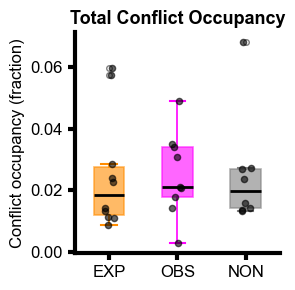

In [72]:
import scipy

# ── Add total conflict occupancy to conf_df ────────────────────────────────────
# Recompute from session_dfs so we have it as a fraction of total recording time

def compute_total_conflict_occupancy(session_dfs):
    """
    For each animal, total conflict occupancy = 
    frames where ANY attack behavior is active / total frames across all sessions.
    """
    records = []
    animal_sessions = {}
    for (animal, session, group), df in session_dfs.items():
        key = (animal, group)
        if key not in animal_sessions:
            animal_sessions[key] = []
        animal_sessions[key].append((session, df))

    for (animal, group), sess_list in animal_sessions.items():
        sess_list = sorted(sess_list, key=lambda x: x[0])
        concat_df = pd.concat([df for _, df in sess_list], ignore_index=True)

        conflict_mask = np.zeros(len(concat_df), dtype=bool)
        for beh in CONFLICT_BEHAVIORS:
            conflict_mask |= (concat_df[beh].values == 1)

        occupancy = conflict_mask.sum() / len(concat_df)
        records.append({
            'animal':   animal,
            'group':    group,
            'occupancy': occupancy,
        })

    return pd.DataFrame(records)

total_conf_occ = compute_total_conflict_occupancy(session_dfs)

# ── Stats ──────────────────────────────────────────────────────────────────────
groups_data = [
    total_conf_occ[total_conf_occ['group'] == g]['occupancy'].dropna().values
    for g in GROUP_ORDER
]
valid_groups = [g for g in groups_data if len(g) >= 3]
parametric   = test_normality(valid_groups)

if len(valid_groups) >= 2:
    if parametric:
        stat, p_omni = f_oneway(*valid_groups)
        test_label   = 'one-way ANOVA'
    else:
        stat, p_omni = kruskal(*valid_groups)
        test_label   = 'Kruskal-Wallis'
else:
    p_omni, test_label = np.nan, 'n/a'

posthoc = posthoc_tests(groups_data, GROUP_ORDER, parametric)

print(f'\n{"="*75}')
print(f'TOTAL CONFLICT OCCUPANCY | {test_label}  stat={stat:.3f}  p={p_omni:.4f}')
print(f'{"="*75}')
print(f'  {"Comparison":<18} {"Test":<8} {"Stat":>10} '
      f'{"p_raw":>10} {"p_corr":>10} {"Sig":>5} '
      f'{"n1":>4} {"n2":>4}')
print(f'  {"─"*65}')
for ph in posthoc:
    sig    = get_sig(ph['p_corr'])
    stat_s = f'{ph["stat"]:>10.3f}'  if not np.isnan(ph['stat'])  else '       n/a'
    p_r_s  = f'{ph["p_raw"]:>10.4f}' if not np.isnan(ph['p_raw']) else '       n/a'
    p_c_s  = f'{ph["p_corr"]:>10.4f}'if not np.isnan(ph['p_corr'])else '       n/a'
    print(f'  {ph["group1"]} vs {ph["group2"]:<10} {ph["test"]:<8} '
          f'{stat_s} {p_r_s} {p_c_s} {sig:>5} '
          f'{ph["n1"]:>4} {ph["n2"]:>4}')
print(f'{"="*75}')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3, 3))

for pi, (g, pts) in enumerate(zip(GROUP_ORDER, groups_data)):
    color = GROUP_COLORS[g]
    if len(pts) == 0:
        continue
    ax.boxplot(pts,
               positions=[pi], widths=0.45, patch_artist=True,
               showfliers=True,
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=color, alpha=0.6,
                             linewidth=1.2, edgecolor=color),
               whiskerprops=dict(color=color, linewidth=1.2),
               capprops=dict(color=color, linewidth=1.5),
               flierprops=dict(marker='o', color=color,
                               markeredgecolor='black',
                               markersize=4, alpha=0.5))
    jitter = np.random.default_rng(42 + pi).uniform(-0.08, 0.08, size=len(pts))
    ax.scatter(np.full(len(pts), pi) + jitter, pts,
               color='black', s=20, alpha=0.6, zorder=5)

# Significance brackets
ax.autoscale()
y_max = ax.get_ylim()[1]
step  = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12
for level, res in enumerate(posthoc):
    sig = get_sig(res['p_corr'])
    if sig in ('', 'ns'):
        continue
    g1_idx = GROUP_ORDER.index(res['group1'])
    g2_idx = GROUP_ORDER.index(res['group2'])
    y_br   = y_max + step * (level + 1)
    ax.plot([g1_idx, g2_idx], [y_br, y_br], color='black', linewidth=2)
    ax.plot([g1_idx, g1_idx], [y_br - step*0.2, y_br], color='black', linewidth=2)
    ax.plot([g2_idx, g2_idx], [y_br - step*0.2, y_br], color='black', linewidth=2)
    ax.text((g1_idx + g2_idx) / 2, y_br, sig,
            ha='center', va='bottom', fontsize=13,
            fontweight='bold', fontfamily='Arial')

ax.set_xticks(np.arange(len(GROUP_ORDER)))
ax.set_xticklabels(GROUP_ORDER, fontsize=14, fontfamily='Arial')
ax.set_ylabel('Conflict occupancy (fraction)', fontsize=12, fontfamily='Arial')
ax.set_title('Total Conflict Occupancy', fontsize=13,
             fontweight='bold', fontfamily='Arial')
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily('Arial')
    tick.set_fontsize(12)
for spine in ax.spines.values():
    spine.set_linewidth(3)
ax.tick_params(length=5, width=3)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('.\\figures\\fig1\\total_conflict_occupancy.svg', dpi=300)
plt.show()


Animal       Group  Atk recv   Atk bouts   Flee total   Flee post-atk   Flee rate    P(flee|atk)    Flee/Atk
------------------------------------------------------------------------------------------
3095         EXP    490        11          0            0               0.0000       0.0000         0.0000
3096         EXP    0          0           0            0               nan          nan            nan
3097         EXP    79         1           0            0               0.0000       0.0000         0.0000
30B          EXP    414        11          0            0               0.0000       0.0000         0.0000
30L          EXP    194        10          413          102             0.5258       0.3000         2.1289
4013         EXP    17         1           0            0               0.0000       0.0000         0.0000
4014         EXP    140        5           0            0               0.0000       0.0000         0.0000
4015         EXP    181        10          0         

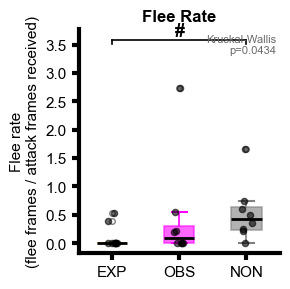


── flee_rate | Kruskal-Wallis p=0.0434 ──
  EXP vs OBS      p_raw=0.2848  p_corr=0.2848  ns
  EXP vs NON      p_raw=0.0195  p_corr=0.0584  #
  OBS vs NON      p_raw=0.1501  p_corr=0.2252  ns


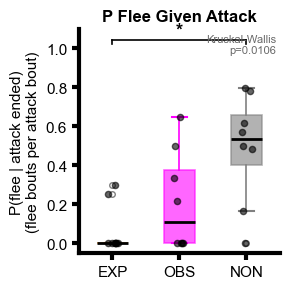


── p_flee_given_attack | Kruskal-Wallis p=0.0106 ──
  EXP vs OBS      p_raw=0.1954  p_corr=0.1954  ns
  EXP vs NON      p_raw=0.0044  p_corr=0.0133  *
  OBS vs NON      p_raw=0.0878  p_corr=0.1318  ns


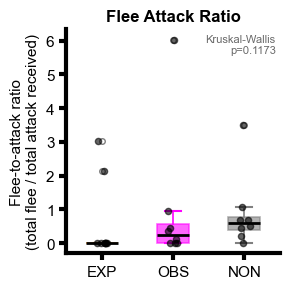


── flee_attack_ratio | Kruskal-Wallis p=0.1173 ──
  EXP vs OBS      p_raw=0.2360  p_corr=0.2445  ns
  EXP vs NON      p_raw=0.0674  p_corr=0.2023  ns
  OBS vs NON      p_raw=0.2445  p_corr=0.2445  ns


In [192]:
def compute_flee_rate_during_conflict(session_dfs, fps=40, post_attack_window_s=2):
    """
    For each animal, compute the flee rate during conflict:
    = flee frames that occur within post_attack_window_s after any attack bout ends
      / total attack frames received (intruder_unilateral + intruder_resistance)
    
    Also computes:
    - raw_flee_during_conflict: flee frames within window / total session frames
    - p_flee_given_attack: P(flee | attack just ended) as conditional probability
    """
    post_window_frames = int(post_attack_window_s * fps)
    records = []

    animal_sessions = {}
    for (animal, session, group), df in session_dfs.items():
        key = (animal, group)
        if key not in animal_sessions:
            animal_sessions[key] = []
        animal_sessions[key].append((session, df))

    for (animal, group), sess_list in animal_sessions.items():
        sess_list = sorted(sess_list, key=lambda x: x[0])
        concat_df = pd.concat([df for _, df in sess_list], ignore_index=True)
        n_frames  = len(concat_df)

        # Attacks received by resident = intruder-initiated behaviors
        attack_received = (
            (concat_df['intruder_resistance'].values == 1) |
            (concat_df['intruder_unilateral'].values == 1)
        ).astype(int)

        flee   = concat_df['resident_flee'].values
        n_flee = flee.sum()

        # Find end frames of each attack bout
        attack_diff = np.diff(attack_received, prepend=0)
        bout_ends   = np.where(attack_diff == -1)[0]  # frame after attack stops

        # Build post-attack window mask
        post_attack_mask = np.zeros(n_frames, dtype=bool)
        for end_frame in bout_ends:
            window_end = min(end_frame + post_window_frames, n_frames)
            post_attack_mask[end_frame:window_end] = True

        # Flee frames that fall within post-attack window
        flee_during_conflict   = (flee == 1) & post_attack_mask
        n_flee_during_conflict = flee_during_conflict.sum()

        # Total attack frames received
        n_attack_received = attack_received.sum()

        # Metrics
        # 1. Flee rate = flee-during-conflict frames / attack-received frames
        flee_rate = (n_flee_during_conflict / n_attack_received
                     if n_attack_received > 0 else np.nan)

        # 2. P(flee | attack just ended) = flee bouts starting in post-attack window
        #    / number of attack bouts
        n_attack_bouts = len(bout_ends)
        flee_diff      = np.diff(flee, prepend=0)
        flee_starts    = np.where(flee_diff == 1)[0]
        flee_bouts_post = np.sum(post_attack_mask[flee_starts]) if len(flee_starts) > 0 else 0
        p_flee_given_attack = (flee_bouts_post / n_attack_bouts
                               if n_attack_bouts > 0 else np.nan)

        # 3. Flee-to-attack ratio (raw)
        flee_attack_ratio = (n_flee / n_attack_received
                             if n_attack_received > 0 else np.nan)

        records.append({
            'animal':               animal,
            'group':                group,
            'n_attack_received':    n_attack_received,
            'n_attack_bouts':       n_attack_bouts,
            'n_flee_total':         n_flee,
            'n_flee_post_attack':   n_flee_during_conflict,
            'flee_rate':            flee_rate,
            'p_flee_given_attack':  p_flee_given_attack,
            'flee_attack_ratio':    flee_attack_ratio,
        })

    return pd.DataFrame(records)

flee_df = compute_flee_rate_during_conflict(session_dfs, fps=FPS,
                                             post_attack_window_s=3)

# ── Print per-animal summary ───────────────────────────────────────────────────
print(f'\n{"="*90}')
print(f'{"Animal":<12} {"Group":<6} {"Atk recv":<10} {"Atk bouts":<11} '
      f'{"Flee total":<12} {"Flee post-atk":<15} {"Flee rate":<12} '
      f'{"P(flee|atk)":<14} {"Flee/Atk"}')
print('-'*90)
for _, row in flee_df.sort_values(['group', 'animal']).iterrows():
    print(f'{row["animal"]:<12} {row["group"]:<6} '
          f'{row["n_attack_received"]:<10.0f} '
          f'{row["n_attack_bouts"]:<11.0f} '
          f'{row["n_flee_total"]:<12.0f} '
          f'{row["n_flee_post_attack"]:<15.0f} '
          f'{row["flee_rate"]:<12.4f} '
          f'{row["p_flee_given_attack"]:<14.4f} '
          f'{row["flee_attack_ratio"]:.4f}')

# ── Plot + stats for each flee metric ─────────────────────────────────────────
FLEE_METRICS = {
    'flee_rate':           'Flee rate\n(flee frames / attack frames received)',
    'p_flee_given_attack': 'P(flee | attack ended)\n(flee bouts per attack bout)',
    'flee_attack_ratio':   'Flee-to-attack ratio\n(total flee / total attack received)',
}

os.makedirs('./figures/fig1/', exist_ok=True)

for metric, ylabel in FLEE_METRICS.items():
    fig, ax = plt.subplots(figsize=(3, 3))

    groups_data = [
        flee_df[flee_df['group'] == g][metric].dropna().values
        for g in GROUP_ORDER
    ]

    # Omnibus
    valid_groups = [g for g in groups_data if len(g) >= 3]
    parametric   = test_normality(valid_groups)
    if len(valid_groups) >= 2:
        if parametric:
            stat, p_omni = f_oneway(*valid_groups)
            test_label   = 'one-way ANOVA'
        else:
            stat, p_omni = kruskal(*valid_groups)
            test_label   = 'Kruskal-Wallis'
    else:
        p_omni, test_label = np.nan, 'n/a'

    posthoc = posthoc_tests(groups_data, GROUP_ORDER, parametric)

    # Boxplots + dots
    for pi, (g, pts) in enumerate(zip(GROUP_ORDER, groups_data)):
        color = GROUP_COLORS[g]
        if len(pts) == 0:
            continue
        ax.boxplot(pts,
                   positions=[pi], widths=0.45, patch_artist=True,
                   showfliers=True,
                   medianprops=dict(color='black', linewidth=2),
                   boxprops=dict(facecolor=color, alpha=0.6,
                                 linewidth=1.2, edgecolor=color),
                   whiskerprops=dict(color=color, linewidth=1.2),
                   capprops=dict(color=color, linewidth=1.5),
                   flierprops=dict(marker='o', color=color,
                                   markeredgecolor='black',
                                   markersize=4, alpha=0.5))
        jitter = np.random.default_rng(42 + pi).uniform(-0.08, 0.08, size=len(pts))
        ax.scatter(np.full(len(pts), pi) + jitter, pts,
                   color='black', s=20, alpha=0.6, zorder=5)

    # Significance brackets
    ax.autoscale()
    y_max = ax.get_ylim()[1]
    step  = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12
    for level, res in enumerate(posthoc):
        sig = get_sig(res['p_corr'])
        if sig in ('', 'ns'):
            continue
        g1_idx = GROUP_ORDER.index(res['group1'])
        g2_idx = GROUP_ORDER.index(res['group2'])
        y_br   = y_max + step * (level + 1)
        ax.plot([g1_idx, g2_idx], [y_br, y_br], color='black', linewidth=1.2)
        ax.plot([g1_idx, g1_idx], [y_br - step*0.2, y_br], color='black', linewidth=1.2)
        ax.plot([g2_idx, g2_idx], [y_br - step*0.2, y_br], color='black', linewidth=1.2)
        ax.text((g1_idx + g2_idx) / 2, y_br, sig,
                ha='center', va='bottom', fontsize=13,
                fontweight='bold', fontfamily='Arial')

    ax.set_xticks(np.arange(len(GROUP_ORDER)))
    ax.set_xticklabels(GROUP_ORDER, fontsize=13, fontfamily='Arial')
    ax.set_ylabel(ylabel, fontsize=11, fontfamily='Arial')
    ax.set_title(metric.replace('_', ' ').title(),
                 fontsize=12, fontweight='bold', fontfamily='Arial')

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial')
        tick.set_fontsize(11)
    for spine in ax.spines.values():
        spine.set_linewidth(3)
    ax.tick_params(axis='both', length=5, width=3)

    p_str = f'p={p_omni:.4f}' if not np.isnan(p_omni) else 'p=NA'
    ax.text(0.98, 0.98, f'{test_label}\n{p_str}',
            transform=ax.transAxes, fontsize=8, fontfamily='Arial',
            ha='right', va='top', color='dimgray')

    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(f'./figures/fig1/flee_{metric}.svg', dpi=300)
    plt.show()
    plt.close()

    print(f'\n── {metric} | {test_label} p={p_omni:.4f} ──')
    for ph in posthoc:
        sig = get_sig(ph['p_corr'])
        print(f'  {ph["group1"]} vs {ph["group2"]:<8} '
              f'p_raw={ph["p_raw"]:.4f}  p_corr={ph["p_corr"]:.4f}  {sig}')

In [66]:
# Save all dfs for future analysis

occ_df.to_pickle('hand-annotated_fight_occupancies.pickle')
total_conf_occ.to_pickle('hand-annotated_conflict_occupancies.pickle')

# Gq hand-scored behaviors

In [53]:
boris_dir = 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\'
boris_files = np.sort([boris_dir + x for x in os.listdir(boris_dir) if '.csv' in x and '._' not in x])
print('Sample boris files:')
print(boris_files)

Sample boris files:
['C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\77355B_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\77355R_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\82017L2_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\8605R_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\8606L_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\8606R2_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\GqC1_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\GqC2_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\GqC3_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\GqC4_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\GqC5_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\GqC6_d6_CNO_t1.csv'
 'C:\\Users\\FalknerLab\\Desktop\\Gq_labels\\GqC7_d6_CNO_t1.csv']



=== 77355B_d6_CNO_t1.csv | 77355B | Vgat+/- | t1 ===
  Format A failed (Format A columns not found), trying Format B...
  Parsed as Format B (flat CSV with Image index)
  Behaviors found: ['resident_attack_with_resistance' 'intruder_attack_with_resistance'
 'resident_unilateral_attack']
  resident_unilateral                37 frames  (0.93s)
  intruder_unilateral                 0 frames  (0.00s)
  resident_resistance               504 frames  (12.60s)
  intruder_resistance                71 frames  (1.77s)
  resident_flee                       0 frames  (0.00s)

=== 77355R_d6_CNO_t1.csv | 77355R | Vgat+/- | t1 ===
  Format A failed (Format A columns not found), trying Format B...
  Parsed as Format B (flat CSV with Image index)
  Behaviors found: ['resident_attack_with_resistance' 'intruder_attack_with_resistance']
  resident_unilateral                 0 frames  (0.00s)
  intruder_unilateral                 0 frames  (0.00s)
  resident_resistance                73 frames  (1.82s)
  i

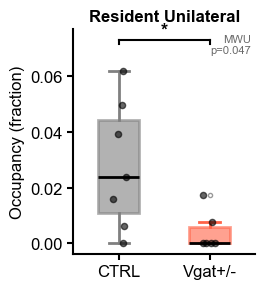

resident_unilateral: MWU p=0.0473  CTRL=0.0280  DREADD=0.0042


c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


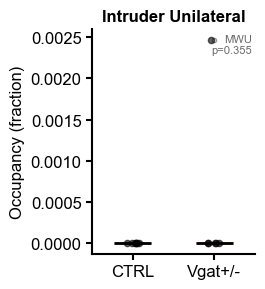

intruder_unilateral: MWU p=0.3545  CTRL=0.0000  DREADD=0.0004


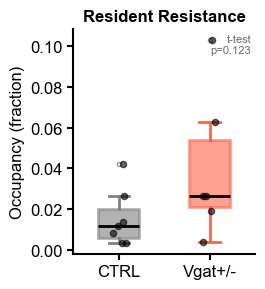

resident_resistance: t-test p=0.1229  CTRL=0.0154  DREADD=0.0402


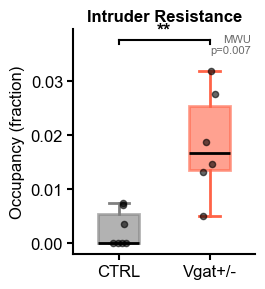

intruder_resistance: MWU p=0.0074  CTRL=0.0026  DREADD=0.0184


c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


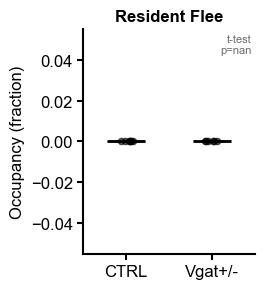

resident_flee: t-test p=nan  CTRL=0.0000  DREADD=0.0000


In [54]:
# ── Behavior constants (same as before) ───────────────────────────────────────
RESIDENT_UNILATERAL = ['resident_unilateral_attack']
INTRUDER_UNILATERAL = ['intruder_unilateral_attack']
RESIDENT_RESISTANCE = ['resident_attack_with_resistance', 'fight_from_resident_with_resistance']
INTRUDER_RESISTANCE = ['intruder_attack_with_resistance', 'fight_from_intruder_with_resistance']
RESIDENT_FLEE       = ['resident_flee']

ALL_BEHAVIOR_GROUPS = {
    'resident_unilateral': RESIDENT_UNILATERAL,
    'intruder_unilateral': INTRUDER_UNILATERAL,
    'resident_resistance': RESIDENT_RESISTANCE,
    'intruder_resistance': INTRUDER_RESISTANCE,
    'resident_flee':       RESIDENT_FLEE,
}

# ── Updated filename parser — handles CNO sessions ────────────────────────────
def parse_filename_cno(fname):
    """
    Parses filenames like:
      8605B_d6_CNO_t1.csv   -> animal=8605B,  group=CTRL, session=1
      GqC1_d6_CNO_t1.csv   -> animal=GqC1,   group=DREADD, session=1
    """
    base  = os.path.basename(fname).replace('.csv', '')
    match = re.match(r'^(.+?)_d\d+_CNO_t(\d+)$', base)
    if match:
        animal  = match.group(1)
        session = int(match.group(2))
        group   = 'CTRL' if animal.startswith('GqC') else 'Vgat+/-'
        return animal, session, group
    return None, None, None

# ── Load all CNO sessions ──────────────────────────────────────────────────────
def load_cno_sessions(boris_files, boris_fps=40):
    session_dfs = {}

    for path in boris_files:
        animal, session, group = parse_filename_cno(path)
        if animal is None:
            print(f'  Could not parse: {os.path.basename(path)}')
            continue

        print(f'\n=== {os.path.basename(path)} | {animal} | {group} | t{session} ===')
        behs = format_boris_new(path, boris_fps=boris_fps)

        if behs is None:
            print(f'  Skipping — could not parse.')
            continue

        n_frames = int(behs['Frame'].max()) + 1

        arrays = {}
        for col_name, behavior_list in ALL_BEHAVIOR_GROUPS.items():
            col = np.zeros(n_frames, dtype=int)
            for beh in behavior_list:
                if beh in behs['Behavior'].values:
                    frames = extract_frames_from_boris(behs, beh)
                    if len(frames):
                        col[np.clip(frames, 0, n_frames - 1)] = 1
            arrays[col_name] = col

        df = pd.DataFrame(arrays)
        df.insert(0, 'animal',  animal)
        df.insert(1, 'group',   group)
        df.insert(2, 'session', session)
        df.insert(3, 'time_s',  np.arange(n_frames) / boris_fps)

        key = (animal, session, group)
        session_dfs[key] = df

        for col in ALL_BEHAVIOR_GROUPS:
            n = arrays[col].sum()
            print(f'  {col:<30} {n:>6} frames  ({n/boris_fps:.2f}s)')

    print(f'\n{"="*60}')
    print(f'Loaded {len(session_dfs)} sessions total.')
    return session_dfs

# ── Run ────────────────────────────────────────────────────────────────────────
cno_files = boris_files

cno_session_dfs = load_cno_sessions(cno_files, boris_fps=40)
cno_master_df   = pd.concat(cno_session_dfs.values(), ignore_index=True)

print(f'\nCNO master DataFrame: {cno_master_df.shape}')
print(cno_master_df.groupby('group')[['animal']].nunique())

# ── Occupancy per animal ───────────────────────────────────────────────────────
def compute_occupancy_cno(session_dfs):
    records = []
    for (animal, session, group), df in session_dfs.items():
        n_total = len(df)
        for beh in ALL_BEHAVIOR_GROUPS:
            n_active = df[beh].sum()
            records.append({
                'animal':    animal,
                'group':     group,
                'behavior':  beh,
                'occupancy': n_active / n_total if n_total > 0 else np.nan,
            })
    return pd.DataFrame(records)

cno_occ_df = compute_occupancy_cno(cno_session_dfs)

# ── Plot — same boxplot style as before ───────────────────────────────────────
GROUP_ORDER_CNO  = ['CTRL', 'Vgat+/-']
GROUP_COLORS_CNO = {'CTRL': 'gray', 'Vgat+/-': 'tomato'}
BEHAVIORS        = list(ALL_BEHAVIOR_GROUPS.keys())

# os.makedirs('./figures/cno/', exist_ok=True)

for beh in BEHAVIORS:
    fig, ax = plt.subplots(figsize=(2.75, 3))
    beh_df  = cno_occ_df[cno_occ_df['behavior'] == beh]

    groups_data = [
        beh_df[beh_df['group'] == g]['occupancy'].dropna().values
        for g in GROUP_ORDER_CNO
    ]

    # Stats
    valid_groups = [g for g in groups_data if len(g) >= 2]
    if len(valid_groups) == 2:
        _, p_a = shapiro(groups_data[0]) if len(groups_data[0]) >= 3 else (None, 0)
        _, p_b = shapiro(groups_data[1]) if len(groups_data[1]) >= 3 else (None, 0)
        parametric = p_a > 0.05 and p_b > 0.05
        if parametric:
            _, p_val   = ttest_ind(groups_data[0], groups_data[1])
            test_label = 't-test'
        else:
            _, p_val   = mannwhitneyu(groups_data[0], groups_data[1],
                                       alternative='two-sided')
            test_label = 'MWU'
    else:
        p_val, test_label = np.nan, 'n/a'

    # Boxplots
    positions = [1, 2]
    box = ax.boxplot(groups_data,
                     positions=positions,
                     patch_artist=True, widths=0.45,
                     medianprops=dict(color='black', linewidth=2),
                     whiskerprops=dict(linewidth=2),
                     capprops=dict(linewidth=2),
                     flierprops=dict(marker='o', markersize=3,
                                     markeredgecolor='black', alpha=0.4))

    for patch, g in zip(box['boxes'], GROUP_ORDER_CNO):
        color = GROUP_COLORS_CNO[g]
        patch.set_facecolor(color); patch.set_edgecolor(color)
        patch.set_alpha(0.6);       patch.set_linewidth(2)
    for whisker, color in zip(box['whiskers'],
                               [GROUP_COLORS_CNO[g]
                                for g in GROUP_ORDER_CNO for _ in (0,1)]):
        whisker.set_color(color); whisker.set_linewidth(2)
    for cap, color in zip(box['caps'],
                           [GROUP_COLORS_CNO[g]
                            for g in GROUP_ORDER_CNO for _ in (0,1)]):
        cap.set_color(color); cap.set_linewidth(2)

    # Individual dots
    for j, (data, g) in enumerate(zip(groups_data, GROUP_ORDER_CNO)):
        jitter = np.random.default_rng(42+j).uniform(-0.08, 0.08, size=len(data))
        ax.scatter(np.full(len(data), positions[j]) + jitter,
                   data, color='black', s=20, alpha=0.6, zorder=5)

    # Significance bracket
    ax.autoscale()
    y_max = ax.get_ylim()[1]
    step  = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12
    sig   = get_sig(p_val) if not np.isnan(p_val) else ''
    if sig and sig != 'ns':
        y_br = y_max + step
        ax.plot([1, 2], [y_br, y_br], color='black', linewidth=1.5)
        ax.plot([1, 1], [y_br-step*0.2, y_br], color='black', linewidth=1.5)
        ax.plot([2, 2], [y_br-step*0.2, y_br], color='black', linewidth=1.5)
        ax.text(1.5, y_br, sig, ha='center', va='bottom',
                fontsize=13, fontweight='bold', fontfamily='Arial')

    ax.set_xticks(positions)
    ax.set_xticklabels(GROUP_ORDER_CNO, fontsize=13, fontfamily='Arial')
    ax.set_ylabel('Occupancy (fraction)', fontsize=12, fontfamily='Arial')
    ax.set_title(beh.replace('_', ' ').title(),
                 fontsize=12, fontweight='bold', fontfamily='Arial')
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial'); tick.set_fontsize(12)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.tick_params(axis='both', length=4, width=1.5)
    ax.text(0.98, 0.98, f'{test_label}\np={p_val:.3f}',
            transform=ax.transAxes, fontsize=8, fontfamily='Arial',
            ha='right', va='top', color='dimgray')
    sns.despine(ax=ax)
    plt.tight_layout()
    # plt.savefig(f'./figures/cno/occupancy_{beh}.svg', dpi=300)
    plt.show()
    plt.close()

    print(f'{beh}: {test_label} p={p_val:.4f}  '
          f'CTRL={np.nanmean(groups_data[0]):.4f}  '
          f'DREADD={np.nanmean(groups_data[1]):.4f}')


── Occupancy ──


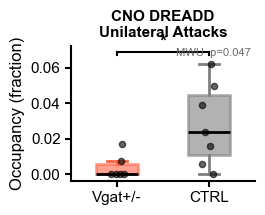

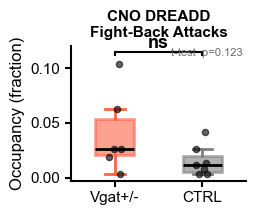

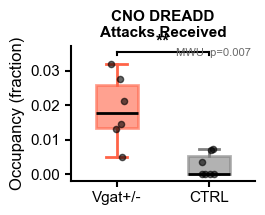


CNO DREADD — occupancy
Behavior                       Test           Stat      p_raw      p_fdr   Sig    Vgat+/-       CTRL
──────────────────────────────────────────────────────────────────────────────────
  unilateral_attacks           MWU           7.000     0.0473     0.0709     #     0.0042     0.0280
  fight-back_attacks           t-test        1.671     0.1229     0.1229    ns     0.0402     0.0154
  attacks_received             MWU          40.000     0.0074     0.0221     *     0.0188     0.0026

── Latency ──


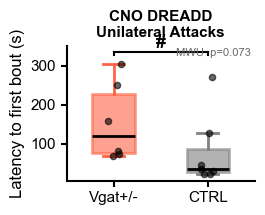

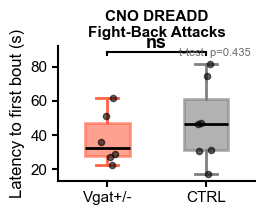

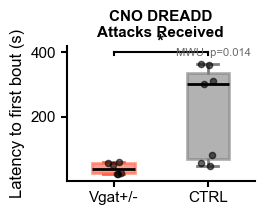


CNO DREADD — latency_s
Behavior                       Test           Stat      p_raw      p_fdr   Sig    Vgat+/-       CTRL
──────────────────────────────────────────────────────────────────────────────────
  unilateral_attacks           MWU          34.000     0.0734     0.1101    ns   156.7667    79.1143
  fight-back_attacks           t-test       -0.809     0.4354     0.4354    ns    37.9125    47.0464
  attacks_received             MWU           4.000     0.0140     0.0420     *    39.7208   216.8036


In [58]:
def plot_cno_boxplots(df, value_col, ylabel, title_prefix,
                      behaviors=COMBINED_BEHAVIORS_CNO, save_dir='./figures/cno/'):
    os.makedirs(save_dir, exist_ok=True)

    # ── collect stats across behaviors for FDR correction ─────────────────────
    stats_records = []

    for beh in behaviors:
        fig, ax = plt.subplots(figsize=(2.75, 2.25))
        beh_df  = df[df['behavior'] == beh]

        groups_data = [
            beh_df[beh_df['group'] == g][value_col].dropna().values
            for g in GROUP_ORDER_CNO
        ]

        valid = [g for g in groups_data if len(g) >= 2]
        if len(valid) == 2:
            _, p_a = shapiro(groups_data[0]) if len(groups_data[0]) >= 3 \
                     else (None, 0.0)
            _, p_b = shapiro(groups_data[1]) if len(groups_data[1]) >= 3 \
                     else (None, 0.0)
            if p_a > 0.05 and p_b > 0.05:
                stat_val, p_val = ttest_ind(groups_data[0], groups_data[1])
                test_label = 't-test'
            else:
                stat_val, p_val = mannwhitneyu(groups_data[0], groups_data[1],
                                                alternative='two-sided')
                test_label = 'MWU'
        else:
            stat_val, p_val, test_label = np.nan, np.nan, 'n/a'

        stats_records.append({
            'behavior':   beh,
            'test':       test_label,
            'stat':       stat_val,
            'p_raw':      p_val,
            'mean_vgat':  np.nanmean(groups_data[0]),
            'mean_ctrl':  np.nanmean(groups_data[1]),
        })

        # ── Boxplots (unchanged) ───────────────────────────────────────────────
        positions = [1, 2]
        box = ax.boxplot(groups_data,
                         positions=positions,
                         patch_artist=True, widths=0.45,
                         medianprops =dict(color='black', linewidth=2),
                         whiskerprops=dict(linewidth=2),
                         capprops    =dict(linewidth=2),
                         flierprops  =dict(marker='', markersize=0))

        for patch, g in zip(box['boxes'], GROUP_ORDER_CNO):
            c = GROUP_COLORS_CNO[g]
            patch.set_facecolor(c); patch.set_edgecolor(c)
            patch.set_alpha(0.6);   patch.set_linewidth(2)
        for element in ['whiskers', 'caps']:
            for item, color in zip(box[element],
                                    [GROUP_COLORS_CNO[g]
                                     for g in GROUP_ORDER_CNO
                                     for _ in (0, 1)]):
                item.set_color(color); item.set_linewidth(2)

        for j, (data, g) in enumerate(zip(groups_data, GROUP_ORDER_CNO)):
            jitter = np.random.default_rng(42+j).uniform(
                -0.08, 0.08, size=len(data))
            ax.scatter(np.full(len(data), positions[j]) + jitter,
                       data, color='black', s=20, alpha=0.6, zorder=5)

        ax.autoscale()
        y_lo, y_hi = ax.get_ylim()
        step = (y_hi - y_lo) * 0.12
        sig  = get_sig(p_val) if not np.isnan(p_val) else ''
        if sig:
            y_br = y_hi + step * 0.5
            ax.plot([1, 2], [y_br, y_br], 'k-', linewidth=1.5)
            ax.plot([1, 1], [y_br - step*0.2, y_br], 'k-', linewidth=1.5)
            ax.plot([2, 2], [y_br - step*0.2, y_br], 'k-', linewidth=1.5)
            ax.text(1.5, y_br, sig, ha='center', va='bottom',
                    fontsize=13, fontweight='bold', fontfamily='Arial')

        ax.set_xticks(positions)
        ax.set_xticklabels(GROUP_ORDER_CNO, fontsize=12, fontfamily='Arial')
        ax.set_ylabel(ylabel, fontsize=12, fontfamily='Arial')
        ax.set_title(f'{title_prefix}\n{beh.replace("_", " ").title()}',
                     fontsize=11, fontweight='bold', fontfamily='Arial')
        ax.text(0.98, 0.98, f'{test_label}  p={p_val:.3f}',
                transform=ax.transAxes, fontsize=8, fontfamily='Arial',
                ha='right', va='top', color='dimgray')
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontfamily('Arial'); tick.set_fontsize(11)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        ax.tick_params(length=4, width=1.5)
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.savefig(f'{save_dir}{value_col}_{beh}.svg', dpi=300)
        plt.show()
        plt.close()

    # ── FDR correction + summary table ────────────────────────────────────────
    valid_idx = [i for i, r in enumerate(stats_records)
                 if not np.isnan(r['p_raw'])]
    if valid_idx:
        _, p_fdr, _, _ = multipletests(
            [stats_records[i]['p_raw'] for i in valid_idx], method='fdr_bh')
        for rank, i in enumerate(valid_idx):
            stats_records[i]['p_fdr'] = p_fdr[rank]
    for r in stats_records:
        if 'p_fdr' not in r:
            r['p_fdr'] = np.nan

    print(f'\n{"="*82}')
    print(f'{title_prefix} — {value_col}')
    print(f'{"="*82}')
    print(f'{"Behavior":<30} {"Test":<8} {"Stat":>10} {"p_raw":>10} '
          f'{"p_fdr":>10} {"Sig":>5} '
          f'{"Vgat+/-":>10} {"CTRL":>10}')
    print(f'{"─"*82}')
    for r in stats_records:
        sig      = get_sig(r['p_fdr']) if not np.isnan(r['p_fdr']) else 'n/a'
        stat_str = f'{r["stat"]:>10.3f}' if not np.isnan(r['stat']) else '       n/a'
        p_r_str  = f'{r["p_raw"]:>10.4f}' if not np.isnan(r['p_raw']) else '       n/a'
        p_f_str  = f'{r["p_fdr"]:>10.4f}' if not np.isnan(r['p_fdr']) else '       n/a'
        print(f'  {r["behavior"]:<28} {r["test"]:<8} {stat_str} '
              f'{p_r_str} {p_f_str} {sig:>5} '
              f'{r["mean_vgat"]:>10.4f} {r["mean_ctrl"]:>10.4f}')
    print(f'{"="*82}')

# ── Add combined columns to cno_session_dfs ───────────────────────────────────
COMBINED_BEHAVIORS_CNO = {
    'unilateral_attacks': ['resident_unilateral'],
    'fight-back_attacks':  ['resident_resistance'],
    'attacks_received':  ['intruder_unilateral', 'intruder_resistance'],
}

GROUP_ORDER_CNO  = ['Vgat+/-', 'CTRL']
GROUP_COLORS_CNO = {'CTRL': 'gray', 'Vgat+/-': 'tomato'}

for key, df in cno_session_dfs.items():
    for combined_name, source_cols in COMBINED_BEHAVIORS_CNO.items():
        available = [c for c in source_cols if c in df.columns]
        df[combined_name] = (df[available].sum(axis=1) > 0).astype(int)
    cno_session_dfs[key] = df

BEHAVIORS_PLOT = list(COMBINED_BEHAVIORS_CNO.keys())

# ── Recompute occupancy and latency with combined columns ─────────────────────
def compute_occupancy_cno_combined(session_dfs, behaviors=BEHAVIORS_PLOT):
    records = []
    for (animal, session, group), df in session_dfs.items():
        n_total = len(df)
        for beh in behaviors:
            if beh not in df.columns:
                continue
            n_active = df[beh].sum()
            records.append({
                'animal':    animal,
                'group':     group,
                'behavior':  beh,
                'occupancy': n_active / n_total if n_total > 0 else np.nan,
            })
    return pd.DataFrame(records)

def compute_latency_cno_combined(session_dfs, behaviors=BEHAVIORS_PLOT, fps=FPS):
    records = []
    for (animal, session, group), df in session_dfs.items():
        for beh in behaviors:
            if beh not in df.columns:
                continue
            active_frames = np.where(df[beh].values == 1)[0]
            latency_s     = active_frames[0] / fps \
                            if len(active_frames) > 0 else len(df) / fps
            records.append({
                'animal':    animal,
                'group':     group,
                'behavior':  beh,
                'latency_s': latency_s,
                'latency_m': latency_s / 60,
            })
    return pd.DataFrame(records)

cno_occ_df_combined = compute_occupancy_cno_combined(cno_session_dfs)
cno_lat_df_combined = compute_latency_cno_combined(cno_session_dfs)

# ── Plot ──────────────────────────────────────────────────────────────────────
print('\n── Occupancy ──')
plot_cno_boxplots(cno_occ_df_combined, value_col='occupancy',
                  ylabel='Occupancy (fraction)',
                  title_prefix='CNO DREADD',
                  behaviors=BEHAVIORS_PLOT)

print('\n── Latency ──')
plot_cno_boxplots(cno_lat_df_combined, value_col='latency_s',
                  ylabel='Latency to first bout (s)',
                  title_prefix='CNO DREADD',
                  behaviors=BEHAVIORS_PLOT)